
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Tarea 1: Investigación de HDBSCAN y OPTICS</h1>
<br style="clear:both"/>
</div>


**1.** Realice una investigación sobre los algoritmos HDBSCAN y OPTICS. Explique sus fundamentos, parámetros, funcionamiento, ventajas y limitaciones, e incluya imágenes, diagramas y ejemplos que faciliten su comprensión.


### 1.1 HDBSCAN

#### Fundamento

DBSCAN usa un **radio único** $\varepsilon$: pequeño rompe los grupos dispersos, grande fusiona los densos. Con densidades distintas **ningún $\varepsilon$ sirve para todos**.

HDBSCAN no elige radio: **los recorre todos** y conserva los grupos que sobreviven más tiempo al variar la densidad. Ese criterio es la **estabilidad**.


#### Funcionamiento

1. **Distancia al núcleo:** distancia de $x$ a su $k$-ésimo vecino ($k =$ `min_samples`); pequeña = zona densa.

   $$\operatorname{core}_k(x) = d(x,\ k\text{-ésimo vecino de } x)$$

2. **Alcanzabilidad mutua:** reemplaza a la distancia normal y **aleja los puntos de zonas dispersas**, para que un punto aislado no parezca pegado a un cluster denso.

   $$d_{\mathrm{mreach}}(a,b) = \max\{\operatorname{core}_k(a),\ \operatorname{core}_k(b),\ d(a,b)\}$$

3. **Jerarquía:** árbol de expansión mínima (MST) con esas distancias, cortando sus aristas de mayor a menor peso.

4. **Árbol condensado:** las ramas con menos de `min_cluster_size` puntos no son clusters; sus puntos "se caen" del padre.

5. **Selección:** con $\lambda = 1/d$ se eligen los clusters más **estables**; el resto es **ruido (`-1`)**.

   $$\operatorname{Stability}(C) = \sum_{x \in C} \left( \lambda_{\mathrm{death}}(x) - \lambda_{\mathrm{birth}}(C) \right)$$

#### Parámetros

| Parámetro | Al aumentarlo |
|---|---|
| `min_cluster_size` — tamaño mínimo de un cluster real | Menos clusters, más grandes |
| `min_samples` — qué tan estricta es la definición de "denso" | Más ruido, clusters más robustos |
| `cluster_selection_method` — cómo se elige la partición | `'eom'` (defecto) grupos estables; `'leaf'` más subclusters |

Tras ajustar: `labels_` (`-1` = ruido) y `probabilities_` (confianza de pertenencia, 0 a 1).

#### Ventajas y limitaciones

| Ventajas | Limitaciones |
|---|---|
| No hay que fijar `eps` | Sufre la maldición de la dimensionalidad |
| Maneja **densidades variables** | Sensible al escalado y a la métrica |
| Decide solo el nº de clusters, y da confianza por punto | Puede marcar demasiado ruido |
| Robusto al ruido y a formas arbitrarias | Más costoso y menos interpretable que DBSCAN |


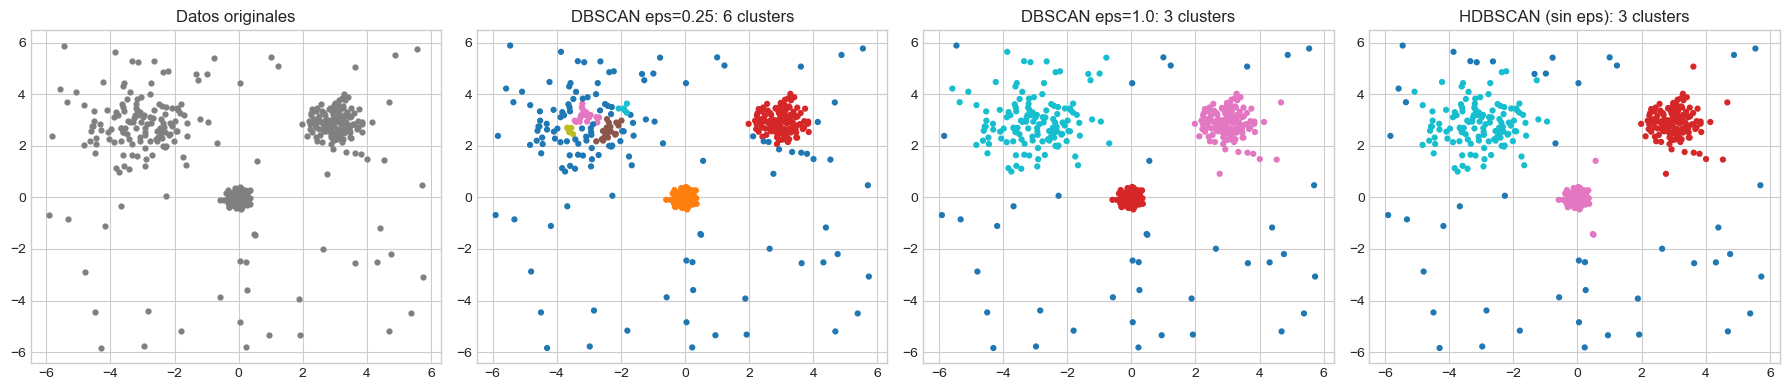

In [5]:
# Tres grupos con DENSIDADES DISTINTAS: el caso donde DBSCAN falla y HDBSCAN funciona.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS

plt.style.use('seaborn-v0_8-whitegrid')


def n_clusters(etiquetas):
    """Cuenta clusters, sin contar el ruido (-1)."""
    return len(set(etiquetas) - {-1})


rng = np.random.default_rng(7)
X_demo = np.vstack([
    rng.normal([0, 0],  0.18, (180, 2)),   # grupo muy denso
    rng.normal([3, 3],  0.45, (140, 2)),   # grupo intermedio
    rng.normal([-3, 3], 0.90, (120, 2)),   # grupo muy disperso
    rng.uniform(-6, 6, (60, 2))])          # ruido de fondo

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].scatter(X_demo[:, 0], X_demo[:, 1], s=12, c='grey')
ax[0].set_title('Datos originales')

for i, eps in enumerate([0.25, 1.00], start=1):
    etiquetas = DBSCAN(eps=eps, min_samples=5).fit_predict(X_demo)
    ax[i].scatter(X_demo[:, 0], X_demo[:, 1], s=12, c=etiquetas, cmap='tab10')
    ax[i].set_title(f'DBSCAN eps={eps}: {n_clusters(etiquetas)} clusters')

hdb_demo = HDBSCAN(min_cluster_size=20).fit(X_demo)
ax[3].scatter(X_demo[:, 0], X_demo[:, 1], s=12, c=hdb_demo.labels_, cmap='tab10')
ax[3].set_title(f'HDBSCAN (sin eps): {n_clusters(hdb_demo.labels_)} clusters')

plt.tight_layout(); plt.show()

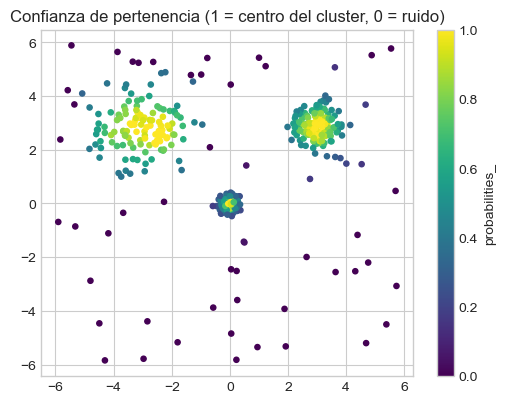

In [2]:
# HDBSCAN entrega ademas una probabilidad de pertenencia por punto.
plt.figure(figsize=(6, 4.5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], s=14, c=hdb_demo.probabilities_, cmap='viridis')
plt.colorbar(label='probabilities_')
plt.title('Confianza de pertenencia (1 = centro del cluster, 0 = ruido)')
plt.show()

### 1.2 OPTICS

#### Fundamento

OPTICS no devuelve clusters sino un **ordenamiento**: recorre los datos por la ruta más densa disponible y anota **qué tan fácil fue alcanzar** cada punto.

Esa curva es el **diagrama de alcanzabilidad**: los **valles** son clusters y los **picos**, las zonas vacías que los separan. Cortarlo a la altura $\varepsilon$ equivale a ejecutar DBSCAN con ese $\varepsilon$, así que contiene la información de *todos* los DBSCAN posibles.

#### Funcionamiento

1. **Distancia al núcleo** de cada punto, igual que en HDBSCAN ($k =$ `min_samples`).

2. **Recorrido** con una cola de prioridad, tomando siempre el punto más fácil de alcanzar. Si $o$ es el punto desde el que se alcanza a $p$, su altura en el diagrama es:

   $$\operatorname{reachability}(p \mid o) = \max\{\operatorname{core\_dist}_k(o),\ d(o,p)\}$$

   El máximo evita que la curva baje artificialmente dentro de una zona poco densa.

3. **Resultado:** `ordering_` (orden del recorrido) y `reachability_` (alturas).

4. **Extracción:** `xi` detecta los valles por caídas relativas de la pendiente; `cluster_method='dbscan'` aplica un corte horizontal a la altura `eps`.

**Cómo leerlo:** valle profundo y ancho = cluster denso; dos valles separados por un pico = clusters bien separados; un valle dentro de otro = subestructura; alturas muy grandes = ruido.

#### Parámetros

| Parámetro | Al aumentarlo |
|---|---|
| `min_samples` — vecinos para la *core distance* | Diagrama más suave, más ruido |
| `xi` — caída relativa mínima para declarar un valle | Menos clusters, más conservador |
| `min_cluster_size` — tamaño mínimo de un valle | Menos clusters, más grandes |

Tras ajustar: `reachability_`, `ordering_`, `core_distances_` y `labels_`.

#### Ventajas y limitaciones

| Ventajas | Limitaciones |
|---|---|
| No hay que fijar `eps` | Más lento que DBSCAN (hasta $O(n^2)$) |
| El **diagrama** es un gran diagnóstico visual | No devuelve clusters directamente |
| El ordenamiento se calcula **una sola vez** | `xi` es poco intuitivo y sensible |
| Maneja densidades variables | Sin probabilidades ni criterio de estabilidad |


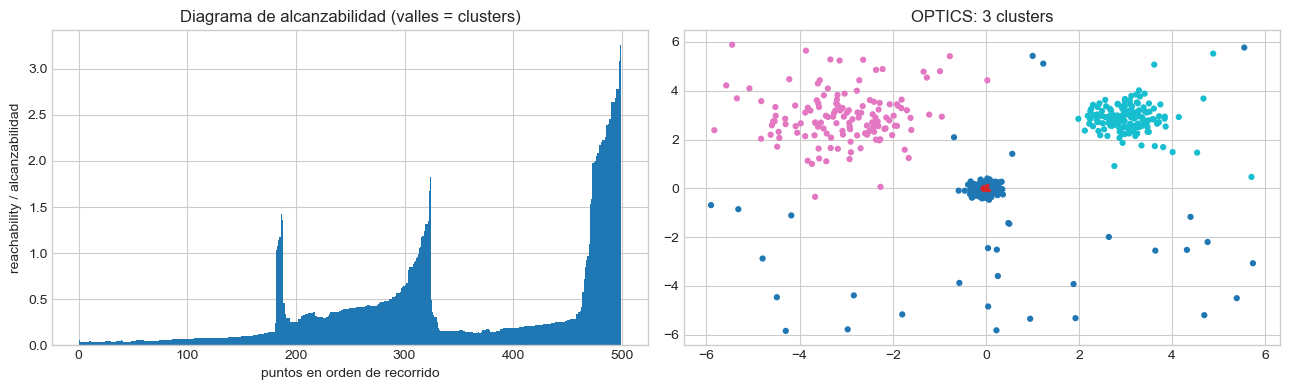

In [9]:
# OPTICS sobre los mismos datos: el diagrama de alcanzabilidad revela la estructura.
opt_demo = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05).fit(X_demo)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Diagrama de alcanzabilidad: cada barra es un punto, en el orden del recorrido
ax[0].bar(np.arange(len(X_demo)), opt_demo.reachability_[opt_demo.ordering_], width=1.0)
ax[0].set_title('Diagrama de alcanzabilidad (valles = clusters)')
ax[0].set_xlabel('puntos en orden de recorrido'); ax[0].set_ylabel('reachability / alcanzabilidad')

ax[1].scatter(X_demo[:, 0], X_demo[:, 1], s=12, c=opt_demo.labels_, cmap='tab10')
ax[1].set_title(f'OPTICS: {n_clusters(opt_demo.labels_)} clusters')

plt.tight_layout(); plt.show()

### 1.3 Comparación

|  | **DBSCAN** | **HDBSCAN** | **OPTICS** |
|---|---|---|---|
| Parámetros | `eps`, `min_samples` | `min_cluster_size`, `min_samples` | `min_samples`, `xi` |
| ¿`eps` único? | Sí | No | No (explora todo el rango) |
| Densidades variables | Limitado | Muy bueno | Muy bueno |
| Salida distintiva | Etiquetas | Jerarquía + confianza por punto | Diagrama de alcanzabilidad |
| Coste | Bajo | Medio-alto | Alto |

- **DBSCAN**: densidad uniforme, método rápido y simple.
- **HDBSCAN**: densidades distintas, partición automática y confianza por punto.
- **OPTICS**: **explorar** la estructura a varias escalas antes de decidir la partición.


### 1.4 Enfoque y funcionamiento

**HDBSCAN:** Crea una estructura de árbol (dendrograma) con todos los grupos posibles. Luego, calcula la "estabilidad" de cada grupo (cuánto sobrevive un grupo a medida que cambia la densidad) y selecciona de forma automática los grupos más estables.

**OPTICS:** No encuentra grupos directamente. En su lugar, ordena los puntos en una lista llamada "diagrama de alcanzabilidad". Este diagrama crea un gráfico con "valles" (que representan los grupos). Tú debes decidir a qué altura cortar el gráfico para definir los grupos.


******

**2.-** Posteriormente, aplique ambos algoritmos al conjunto de datos `wine-clustering.csv`. Analice y visualice la distribución de las variables, prepare adecuadamente los datos y obtenga los clusters identificados por cada modelo. Compare sus resultados mediante gráficas y métricas apropiadas, considerando aspectos como el número de clusters, la cantidad de puntos considerados ruido, la estabilidad y la calidad de las agrupaciones.


### 2.1 Exploración de los datos

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, adjusted_mutual_info_score)

df = pd.read_csv("C:/Users/x/OneDrive - MBGE INTERSISTEMAS/MBGE/DIT/IA/Maestria/Aprendizaje_Automatico_Avanzado_2026/Introducción/data/wine-clustering.csv")
print('Dimensiones:', df.shape, '| Nulos:', df.isna().sum().sum(), '| Duplicados:', df.duplicated().sum())
df.head()

Dimensiones: (178, 13) | Nulos: 0 | Duplicados: 0


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Las 13 variables están en **escalas muy distintas** (`Proline` llega a ~1680 y `Hue` se mueve entre 0.4 y 1.7). Como los tres algoritmos trabajan con **distancias**, sin estandarizar el resultado lo decidiría casi por completo `Proline`.

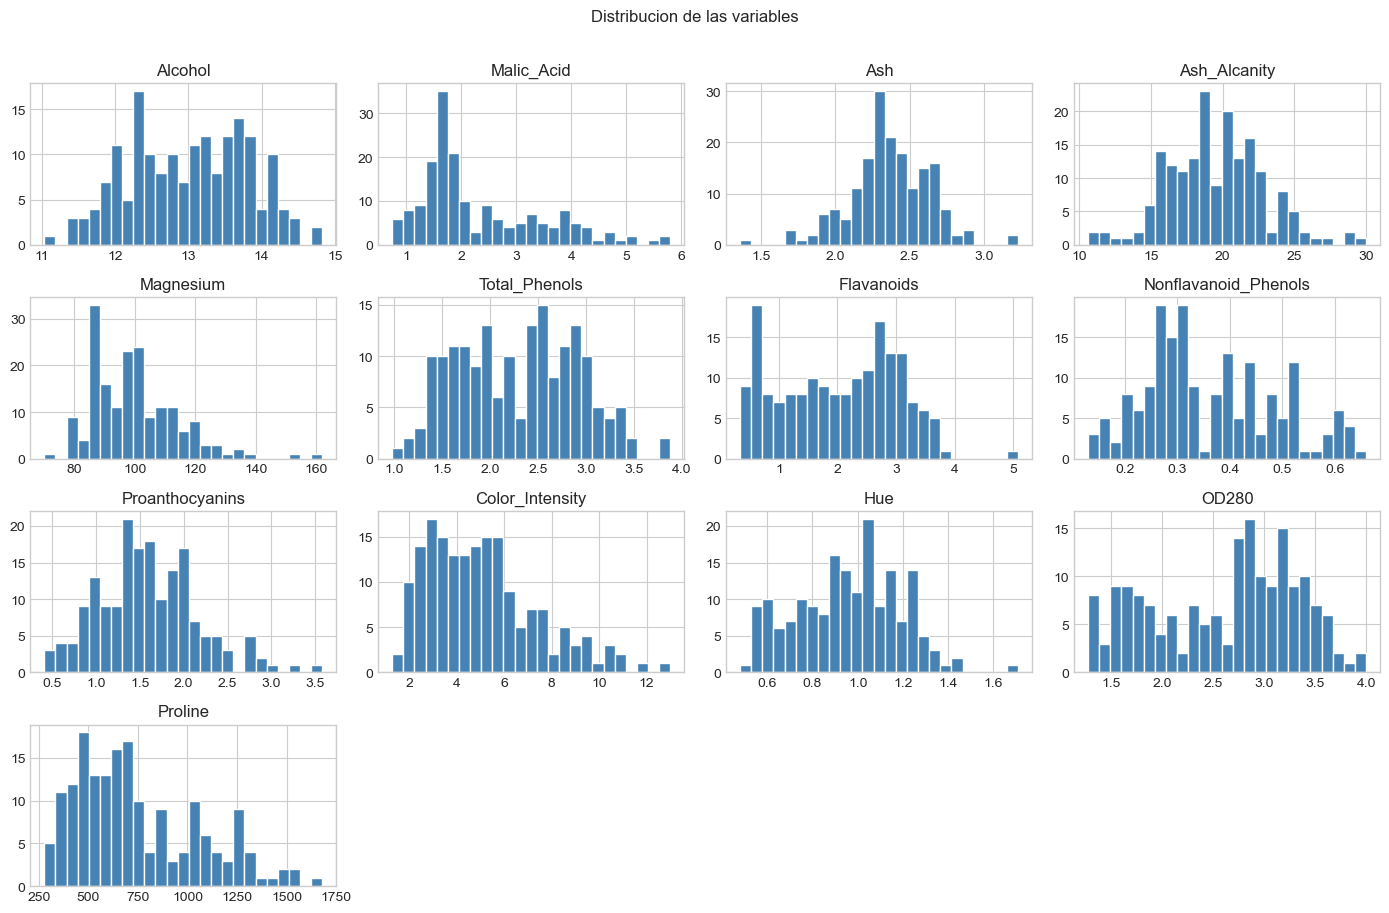

In [15]:
# Distribucion de las 13 variables
df.hist(bins=25, figsize=(14, 9), color='steelblue', edgecolor='white')
plt.suptitle('Distribucion de las variables', y=1.01)
plt.tight_layout(); plt.show()

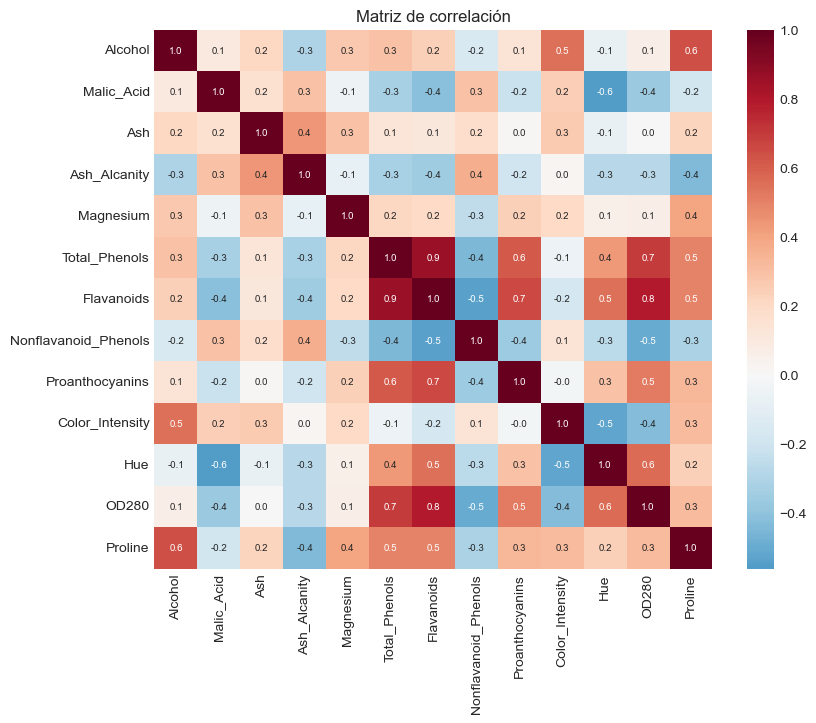

In [16]:
# Mostramos matriz de correlación
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), cmap='RdBu_r', center=0, annot=True, fmt='.1f', annot_kws={'size': 7})
plt.title('Matriz de correlación')
plt.show()

### 2.2 Preparación de los datos

1. **Estandarizar** con `StandardScaler`, porque los tres algoritmos son métodos de distancia.
2. **Reducir dimensión con PCA**, a 2 componentes.

Varianza explicada: [0.362 0.192] | Total: 0.554


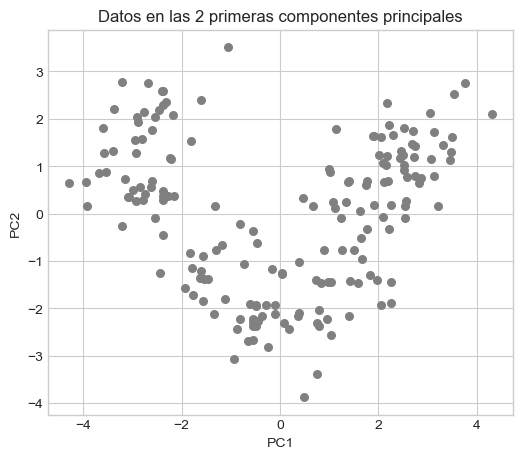

In [17]:
# Escalado + PCA a 2 componentes
X_escalado = StandardScaler().fit_transform(df)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

print('Varianza explicada:', pca.explained_variance_ratio_.round(3), '| Total:', pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30, c='grey')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Datos en las 2 primeras componentes principales')
plt.show()

### 2.3 Criterio de evaluación

Al ser no supervisado, los parámetros se eligen con **métricas internas**: **Silhouette** (↑ mejor), **Davies–Bouldin** (↓ mejor) y **Calinski–Harabasz** (↑ mejor). Las tres se calculan **excluyendo el ruido**, porque la etiqueta `-1` no es un cluster sino un cajón de puntos heterogéneos.


In [18]:
# Funciones auxiliares para evaluar particiones y elegir la mejor
def resumen(etiquetas, X):
    valido = etiquetas != -1
    n = len(set(etiquetas) - {-1})
    return {'n_clusters': n,
            'pct_ruido': round(100 * (~valido).mean(), 1),
            'silhouette': round(silhouette_score(X[valido], etiquetas[valido]), 3) if n >= 2 else np.nan,
            'davies_bouldin': round(davies_bouldin_score(X[valido], etiquetas[valido]), 3) if n >= 2 else np.nan,
            'calinski_harabasz': round(calinski_harabasz_score(X[valido], etiquetas[valido]), 1) if n >= 2 else np.nan}

# Funcion para elegir la mejor configuración de clustering según la métrica silhouette
def elegir_mejor(tabla):
    ok = tabla[(tabla['n_clusters'] >= 2) & (tabla['pct_ruido'] <= 30)]
    return ok.sort_values('silhouette', ascending=False).iloc[0]

### 2.4 HDBSCAN

In [19]:
# Busqueda de parametros
filas = []
for mcs in [5, 8, 10, 12, 15, 20, 25, 30]:
    for ms in [3, 5, 8, 10, 15]:
        etiquetas = HDBSCAN(min_cluster_size=mcs, min_samples=ms).fit_predict(X_pca)
        filas.append({'min_cluster_size': mcs, 'min_samples': ms, **resumen(etiquetas, X_pca)})

tabla_h = pd.DataFrame(filas)
mejor_h = elegir_mejor(tabla_h)
print('Mejor configuracion HDBSCAN:'); print(mejor_h.to_string())

Mejor configuracion HDBSCAN:
min_cluster_size      15.000
min_samples            8.000
n_clusters             3.000
pct_ruido             25.800
silhouette             0.642
davies_bouldin         0.475
calinski_harabasz    384.000


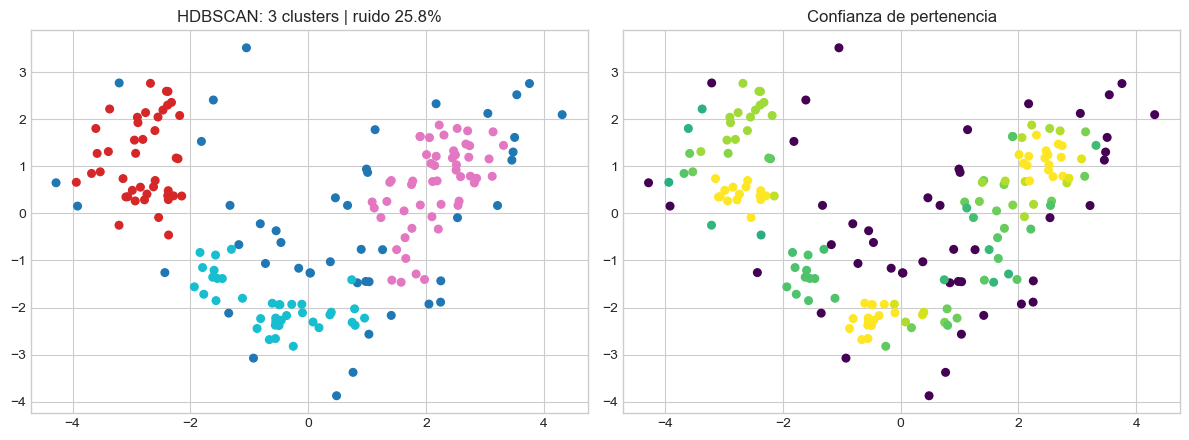

In [ ]:
# Modelo final de HDBSCAN
hdb = HDBSCAN(min_cluster_size=int(mejor_h['min_cluster_size']),
              min_samples=int(mejor_h['min_samples'])).fit(X_pca)
labels_hdb = hdb.labels_

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], s=30, c=labels_hdb, cmap='tab10')
ax[0].set_title(f'HDBSCAN: {n_clusters(labels_hdb)} clusters | ruido {mejor_h["pct_ruido"]}%')
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], s=30, c=hdb.probabilities_, cmap='viridis')
ax[1].set_title('Confianza de pertenencia')
plt.tight_layout(); plt.show()


### 2.5 OPTICS

In [21]:
# Busqueda de parametros
filas = []
for ms in [5, 8, 10, 12, 15, 20, 25]:
    for xi in [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15]:
        etiquetas = OPTICS(min_samples=ms, xi=xi, min_cluster_size=0.05).fit_predict(X_pca)
        filas.append({'min_samples': ms, 'xi': xi, **resumen(etiquetas, X_pca)})

tabla_o = pd.DataFrame(filas)
mejor_o = elegir_mejor(tabla_o)
print('Mejor configuracion OPTICS:'); print(mejor_o.to_string())

Mejor configuracion OPTICS:
min_samples           25.000
xi                     0.050
n_clusters             3.000
pct_ruido             25.300
silhouette             0.694
davies_bouldin         0.394
calinski_harabasz    469.200


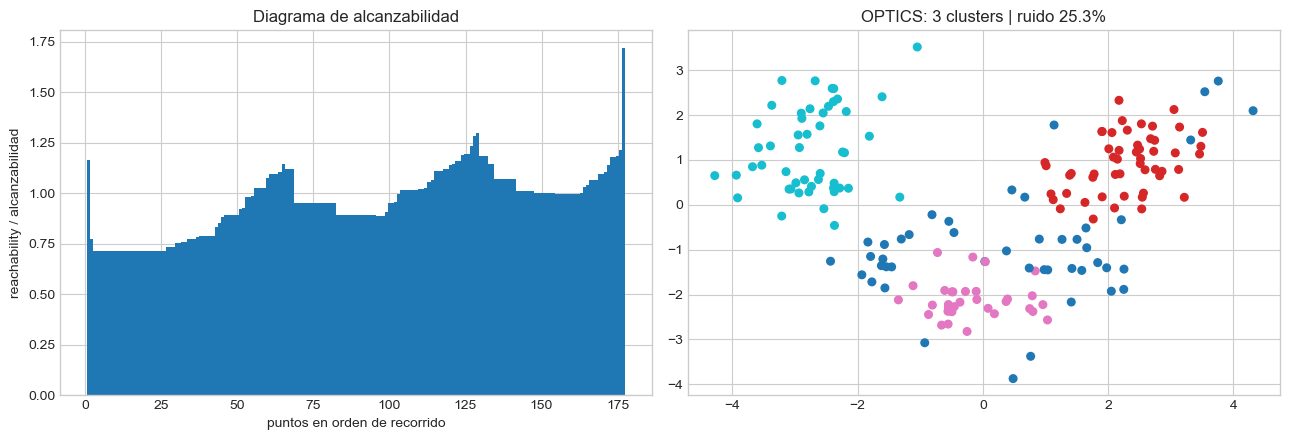

In [24]:
# Modelo final de OPTICS
opt = OPTICS(min_samples=int(mejor_o['min_samples']), xi=float(mejor_o['xi']),
             min_cluster_size=0.05).fit(X_pca)
labels_opt = opt.labels_

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(np.arange(len(X_pca)), opt.reachability_[opt.ordering_], width=1.0)
ax[0].set_title('Diagrama de alcanzabilidad'); ax[0].set_ylabel('reachability / alcanzabilidad'); ax[0].set_xlabel('puntos en orden de recorrido')
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], s=30, c=labels_opt, cmap='tab10')
ax[1].set_title(f'OPTICS: {n_clusters(labels_opt)} clusters | ruido {mejor_o["pct_ruido"]}%')
plt.tight_layout(); plt.show()


### 2.6 Comparación de los dos modelos

Comparamos **número de clusters**, **ruido**, **calidad** (métricas internas) y **estabilidad** (¿sobrevive la partición si cambian los datos?). 

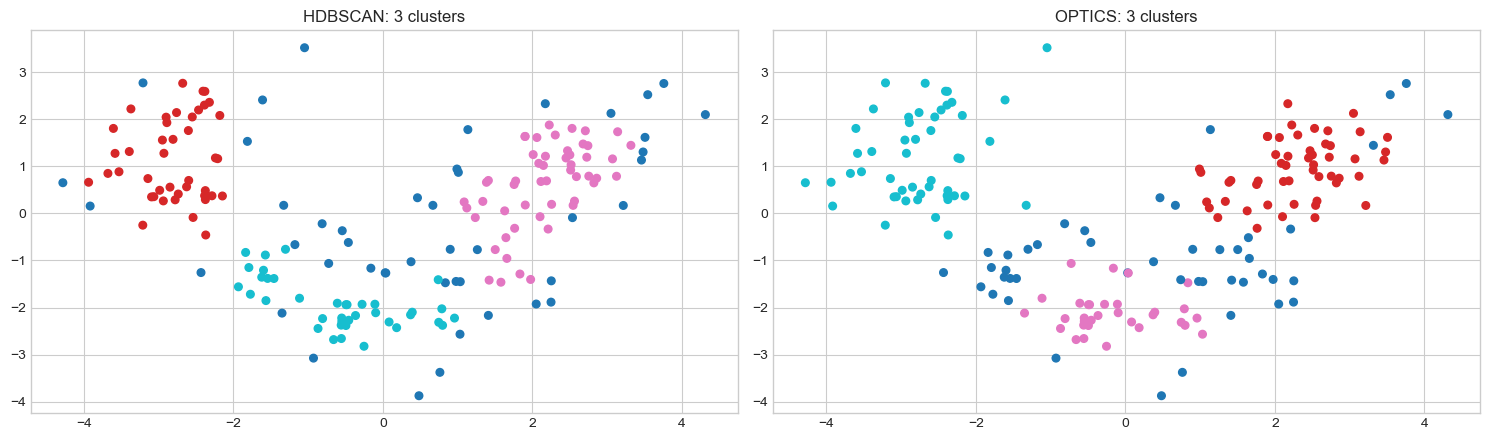

,n_clusters,pct_ruido,silhouette,davies_bouldin,calinski_harabasz
HDBSCAN,3,25.8,0.642,0.475,384.0
OPTICS,3,25.3,0.694,0.394,469.2


In [25]:
# Comparacion visual (con DBSCAN de referencia)
#labels_db = DBSCAN(eps=0.5, min_samples=4).fit_predict(X_pca)
particiones = [('HDBSCAN', labels_hdb), ('OPTICS', labels_opt)]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (nombre, etiquetas) in zip(axes, particiones):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=30, c=etiquetas, cmap='tab10')
    ax.set_title(f'{nombre}: {n_clusters(etiquetas)} clusters')
plt.tight_layout(); plt.show()

comparativa = pd.DataFrame([resumen(l, X_pca) for _, l in particiones],
                           index=[n for n, _ in particiones])
comparativa

In [27]:
# ESTABILIDAD: se remuestrea el 80% de los datos con 30 muestreos.
def estabilidad(modelo, etiquetas_base, n_rep=30):
    rng = np.random.default_rng(42)
    puntajes = []
    for _ in range(n_rep):
        idx = rng.choice(len(X_pca), int(0.8 * len(X_pca)), replace=False)
        puntajes.append(adjusted_rand_score(etiquetas_base[idx], modelo.fit_predict(X_pca[idx])))
    return np.mean(puntajes), np.std(puntajes)


est_h = estabilidad(HDBSCAN(min_cluster_size=int(mejor_h['min_cluster_size']),
                            min_samples=int(mejor_h['min_samples'])), labels_hdb)
est_o = estabilidad(OPTICS(min_samples=int(mejor_o['min_samples']),
                           xi=float(mejor_o['xi']), min_cluster_size=0.05), labels_opt)

print('Estabilidad (30 remuestreos del 80% de los datos):')
print(f'  HDBSCAN: {est_h[0]:.3f} +/- {est_h[1]:.3f}')
print(f'  OPTICS : {est_o[0]:.3f} +/- {est_o[1]:.3f}')

Estabilidad (30 remuestreos del 80% de los datos):
  HDBSCAN: 0.654 +/- 0.167
  OPTICS : 0.562 +/- 0.133


******

**3.-** Finalmente, interprete los resultados y redacte una conclusión argumentada sobre cuál de los dos algoritmos ofrece un mejor desempeño para este

### 3. Conclusión

Ambos algoritmos, **sin que se les indicara el número de grupos**, encontraron **3 clusters**.

| | **HDBSCAN** (`min_cluster_size=15`, `min_samples=8`) | **OPTICS** (`min_samples=25`, `xi=0.05`) |
|---|---|---|
| Nº de clusters | 3 | 3 |
| Ruido | 46 puntos (25.8%) | 45 puntos (25.3%) |
| Silhouette ↑ | 0.642 | **0.694** |
| Davies–Bouldin ↓ | 0.475 | **0.394** |
| Calinski–Harabasz ↑ | 384.0 | **469.2** |
| Estabilidad ↑ | **0.654** | 0.562 |

#### Interpretación

**OPTICS gana en calidad.** Mejor silhouette, mejor Davies–Bouldin y mejor Calinski–Harabasz, **con el mismo nivel de ruido** (45 vs 46 puntos), así que la ventaja no viene de descartar más observaciones.

**HDBSCAN gana en estabilidad** (0.654 vs 0.562). Es coherente con su diseño: selecciona las ramas por **estabilidad**, es decir, se queda justamente con los grupos que persisten al variar la densidad. OPTICS extrae los valles con `xi`, un umbral local.


#### Veredicto

**Para este conjunto de datos, OPTICS ofrece el mejor desempeño**, porque gana en las tres métricas internas y con el mismo nivel de ruido, y porque su diagrama de alcanzabilidad aportó además un diagnóstico visual que HDBSCAN no ofrece.

Por otro lado **HDBSCAN** es más estable, más rápido, más fácil de ajustar (`min_cluster_size` tiene un significado directo, mientras que `xi` es un umbral abstracto) y entrega **probabilidades de pertenencia**, muy útiles en producción. Si el modelo tuviera que reajustarse periódicamente con datos nuevos, esa estabilidad podría pesar más que la diferencia de calidad.